IMPORTS:

In [48]:
from bs4 import BeautifulSoup
import requests
import urllib.request
import zipfile

import os
import pandas as pd
import shutil
import csv
import codecs
import matplotlib.pyplot as plt

CREATING DIRS FOR ZIPS:

In [49]:
# if not os.path.exists('./hydro'):
#     os.mkdir('./hydro')
# if not os.path.exists('./hydro/monthly_hydro_csvs_cleaned'):
#     os.mkdir('./hydro/monthly_hydro_csvs_cleaned')
# if not os.path.exists('./hydro/monthly_hydro_extracted_zips'):
#     os.mkdir('./hydro/monthly_hydro_extracted_zips')

#daily files
if not os.path.exists('./hydro/daily_hydro_csvs_cleaned'):
    os.mkdir('./hydro/daily_hydro_csvs_cleaned')
if not os.path.exists('./hydro/daily_hydro_extracted_zips'):
    os.mkdir('./hydro/daily_hydro_extracted_zips')
if not os.path.exists('./hydro/daily_hydro_csvs_zjaw_cleaned'):
    os.mkdir('./hydro/daily_hydro_csvs_zjaw_cleaned')

DOWNLOADING ZIPS:

In [50]:
# download_dir = './hydro/monthly_hydro_extracted_zips'
download_dir1 = './hydro/daily_hydro_extracted_zips'

# if not os.path.exists(download_dir):
#     os.mkdir(download_dir)

if not os.path.exists(download_dir1):
    os.mkdir(download_dir1)

for i in range(2017, 2022):
    # url = f'https://danepubliczne.imgw.pl/data/dane_pomiarowo_obserwacyjne/dane_hydrologiczne/miesieczne/{i}/'
    url_daily = f'https://danepubliczne.imgw.pl/data/dane_pomiarowo_obserwacyjne/dane_hydrologiczne/dobowe/{i}/'

    # html_page = requests.get(url)
    # soup = BeautifulSoup(html_page.content, 'html.parser')

    html_page_d = requests.get(url_daily)
    soup_d = BeautifulSoup(html_page_d.content, 'html.parser')

    # for link in soup.find_all('a'):
    #     if link.get('href').endswith('.zip'):
            
    #         zip_file = link.get('href')
    #         file_url = url + zip_file
            
    #         download_path = os.path.join(download_dir, zip_file)

    #         urllib.request.urlretrieve(file_url, download_path)

    #         with zipfile.ZipFile(download_path, 'r') as zip_ref:
    #             zip_ref.extractall(download_dir)

    #         os.remove(download_path)

    for link in soup_d.find_all('a'):
        if link.get('href').endswith('.zip'):
            
            zip_file = link.get('href')
            file_url = url_daily + zip_file
            
            download_path = os.path.join(download_dir1, zip_file)

            urllib.request.urlretrieve(file_url, download_path)

            with zipfile.ZipFile(download_path, 'r') as zip_ref:
                zip_ref.extractall(download_dir1)

            os.remove(download_path)

copying files to another dir for replacing with cleaned ones:

In [51]:
# src_dir = './hydro/monthly_hydro_extracted_zips'

# dest_dir = './hydro/monthly_hydro_csvs_cleaned'

# for file_name in os.listdir(src_dir):
    
#     file_path = os.path.join(src_dir, file_name)

#     if os.path.isfile(file_path):
#         shutil.copy(file_path, dest_dir)

src_dir = './hydro/daily_hydro_extracted_zips'

dest_dir = './hydro/daily_hydro_csvs_cleaned'

dest_dir1 = './hydro/daily_hydro_csvs_zjaw_cleaned'

for file_name in os.listdir(src_dir):
    if not file_name.startswith('zjaw'):
        file_path = os.path.join(src_dir, file_name)
        if os.path.isfile(file_path):
            shutil.copy(file_path, dest_dir)

for file_name in os.listdir(src_dir):
    if file_name.startswith('zjaw'):
        file_path = os.path.join(src_dir, file_name)
        if os.path.isfile(file_path):
            shutil.copy(file_path, dest_dir1)


CLEANING MONTHLY CSVs:

In [52]:
# directory_m = './hydro/monthly_hydro_csvs_cleaned'


# for file in os.listdir(directory_m):
#     file_path = os.path.join(directory_m, file)

#     with codecs.open(file_path, 'r', encoding='Windows-1250') as f:
#         contents = f.read()

#     with codecs.open(file_path, 'w', encoding='utf-8') as f:
#         f.write(contents)


#     df = pd.read_csv(file_path, encoding='utf-8')

#     df.columns = df.columns.str.strip()
#     df = df.dropna()
#     df = df.drop_duplicates()

    

In [53]:
# for file in os.listdir(directory_m):
#     print(file)
#     file_path = os.path.join(directory_m, file)

#     with open(file_path, 'r', newline='') as f:
#         reader = csv.reader(f)
#         rows = [row for row in reader if 'GŁOGÓW' in row]
        
#     with open('monthly_glogow.csv', 'a', newline='') as output:
#         writer = csv.writer(output)
#         writer.writerows(rows)



ADDING COLUMN NAMES AND DISPLAYING DATA (MONTHLY):

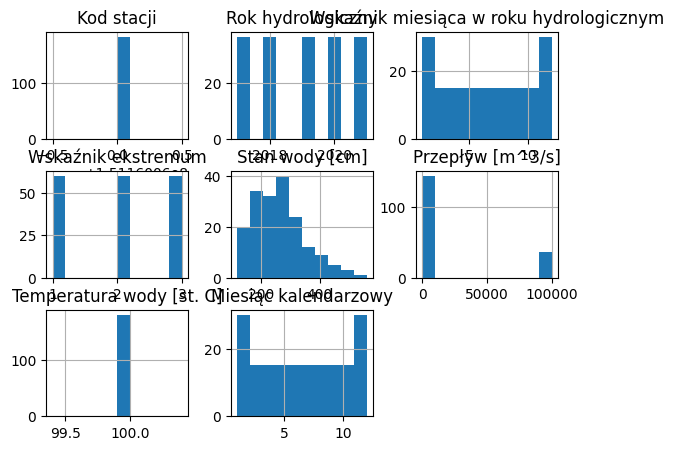

,Kod stacji,Rok hydrologiczny,Wskaźnik miesiąca w roku hydrologicznym,Wskaźnik ekstremum,Stan wody [cm],Przepływ [m^3/s],Temperatura wody [st. C],Miesiąc kalendarzowy
mean,151160060.0,2010.5,6.5,2.0,271.228535,68249.271288,99.9,6.5
min,151160060.0,2000.0,1.0,1.0,109.000000,32.000000,99.9,1.0
max,151160060.0,2021.0,12.0,3.0,686.000000,99999.999000,99.9,12.0


In [54]:
first_row = ['Kod stacji', 'Nazwa stacji', 'Nazwa rzeki/jeziora', 'Rok hydrologiczny', 'Wskaźnik miesiąca w roku hydrologicznym', 'Wskaźnik ekstremum', 'Stan wody [cm]', 'Przepływ [m^3/s]', 'Temperatura wody [st. C]', 'Miesiąc kalendarzowy']

with open('./monthly_glogow.csv', 'r', newline='', encoding='utf-8') as file_r:
    reader_obj = csv.reader(file_r)
    rows = [row for row in reader_obj]

if not first_row in rows:
    rows.insert(0, first_row)

with open('./monthly_glogow.csv', 'w', newline='', encoding='utf-8') as file_w:
    writer_obj = csv.writer(file_w)
    writer_obj.writerows(rows)

df = pd.read_csv('./monthly_glogow.csv', encoding='utf-8')

# df['Kod stacji'] = df['Kod stacji'].astype(int)
# df['Nazwa stacji'] = df['Nazwa stacji'].astype(str)
# df['Nazwa rzeki/jeziora'] = df['Nazwa rzeki/jeziora'].astype(str)
# df['Rok hydrologiczny'] = pd.to_datetime(df['Rok hydrologiczny'])
# df['Wskaźnik miesiąca w roku hydrologicznym'] = pd.to_datetime(df['Wskaźnik miesiąca w roku hydrologicznym'])
# df['Wskaźnik ekstremum'] = df['Wskaźnik ekstremum'].astype(float)
# df['Stan wody [cm]'] = df['Stan wody [cm]'].astype(float)
# df['Przepływ [m^3/s]'] = df['Przepływ [m^3/s]'].astype(float)
# df['Temperatura wody [st.C]'] = df['Temperatura wody [st.C]'].astype(float)
# df['Miesiąc kalendarzowy'] = pd.to_datetime(df['Miesiąc kalendarzowy'])

filtered_df = df[df['Rok hydrologiczny'].isin([2017, 2018, 2019, 2020, 2021, 2022])]
ax = filtered_df.hist(bins=10)

fig = ax[0][0].get_figure()
fig.subplots_adjust(left=0.1, right=0.9, bottom=0.1, top=0.9)

plt.show()

summ = df.describe()
sel = summ.loc[['mean', 'min', 'max']]
sel

CLEANING DAILY CSVs:

In [55]:
directory = './hydro/daily_hydro_csvs_cleaned'


for file in os.listdir(directory):
    file_path = os.path.join(directory, file)

    with codecs.open(file_path, 'r', encoding='Windows-1250') as f:
        contents = f.read()

    with codecs.open(file_path, 'w', encoding='utf-8') as f:
        f.write(contents)

    df = pd.read_csv(file_path, encoding='utf-8')

    df.columns = df.columns.str.strip()
    df = df.dropna()
    df = df.drop_duplicates()


In [56]:
for file in os.listdir(directory):
    file_path = os.path.join(directory, file)

    with open(file_path, 'r', newline='') as f:
        reader = csv.reader(f)
        rows = [row for row in reader if 'GŁOGÓW' in row]
        
    with open('daily_glogow.csv', 'a', newline='') as output:
        writer = csv.writer(output)
        writer.writerows(rows)


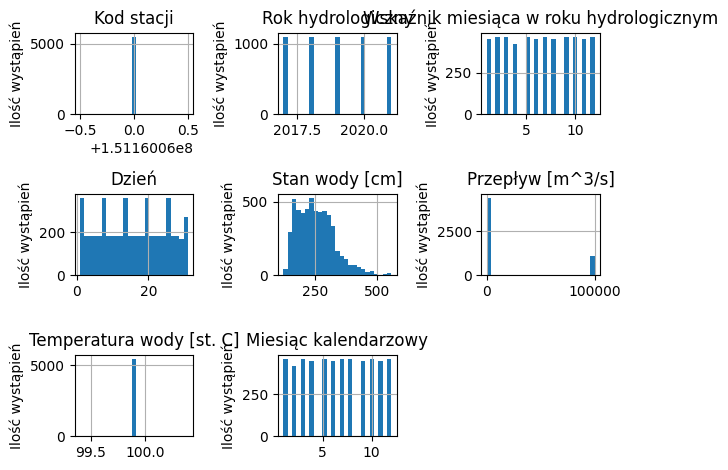

In [61]:
first_row_d = ['Kod stacji', 'Nazwa stacji', 'Nazwa rzeki/jeziora', 'Rok hydrologiczny', 'Wskaźnik miesiąca w roku hydrologicznym', 'Dzień', 'Stan wody [cm]', 'Przepływ [m^3/s]', 'Temperatura wody [st. C]', 'Miesiąc kalendarzowy']

with open('./daily_glogow.csv', 'r', newline='', encoding='utf-8') as file_r:
    reader_obj = csv.reader(file_r)
    rows = [row for row in reader_obj]

if not first_row_d in rows:
    rows.insert(0, first_row_d)

with open('./daily_glogow.csv', 'w', newline='', encoding='utf-8') as file_w:
    writer_obj = csv.writer(file_w)
    writer_obj.writerows(rows)

df = pd.read_csv('./daily_glogow.csv', encoding='utf-8')

# df['Nazwa stacji'].fillna('Unknown', inplace=True)

# df['Nazwa stacji'] = df['Nazwa stacji'].apply(str)


# data_types = {
#     'Kod stacji': int,
#     'Nazwa stacji': str,
#     'Nazwa rzeki/jeziora': str,
#     'Rok hydrologiczny': int,
#     'Wskaźnik miesiąca w roku hydrologicznym': int,
#     'Dzień': int,
#     'Stan wody [cm]': float,
#     'Przepływ [m^3/s]': float,
#     'Temperatura wody [st. C]': float,
#     'Miesiąc kalendarzowy': int
# }

# df = df.astype(data_types)

# extracted_data = ['Stan wody [cm]', 'Przepływ [m^3/s]', 'Temperatura wody [st. C]']

# extracted_data['Dzień'] = pd.to_datetime(['Dzień'])

# weekly_data = extracted_data.groupby(pd.Grouper(key='Dzień', freq='W')).mean().reset_index()


# df['Dzień'] = pd.to_datetime(df['Dzień'])

# print(df.dtypes)

# df.set_index('Dzień', inplace=True)

# weekly_data = df.resample('W').sum()

# weekly_data.reset_index(inplace=True)

# weekly_data.to_csv('weekly_data.csv', index=False)

# weekly_data = df.groupby(pd.Grouper(key='Dzień', freq='W')).mean().reset_index()
# weekly_data = df.resample('W').mean()

# weekly_data.reset_index(inplace=True)

# print(weekly_data[['Dzień', 'Stan wody [cm]', 'Przepływ [m^3/s]', 'Temperatura wody [st. C]']])

# print(df.dtypes)

filtered_df = df[df['Rok hydrologiczny'].isin([2017, 2018, 2019, 2020, 2021, 2022])]
ax = filtered_df.hist(bins=25)

fig = ax[0][0].get_figure()
# fig.subplots_adjust(left=0.1, right=0.9, bottom=0.1, top=0.9, wspace=0.4, hspace=0.4)

# x_labels = ['Kod stacji', 'Nazwa stacji', 'Nazwa rzeki/jeziora', 'Rok hydrologiczny', 'Wskaźnik miesiąca w roku hydrologicznym', 'Dzień', 'Stan wody [cm]', 'Przepływ [m^3/s]', 'Temperatura wody [st. C]', 'Miesiąc kalendarzowy']
# axes = ax.flatten()

for i, subplot in enumerate(ax.flatten()):
    subplot.set_ylabel('Ilość wystąpień')

    plt.tight_layout()

    subplot_path = f'subplot_{i+1}.png'  # Adjust the filename as desired
    fig.savefig(subplot_path)

    plt.clf()
    plt.close(fig)
    # bins = subplot.patches
    # bin_boundaries = [patch.get_x() for patch in bins] + [bins[-1].get_x() + bins[-1].get_width()]
    # bin_labels = [f'{bin_start:.2f}-{bin_end:.2f}' for bin_start, bin_end in zip(bin_boundaries[:-1], bin_boundaries[1:])]
    
    # for i, patch in enumerate(bins):
    #     bin_x = patch.get_x()
    #     bin_width = patch.get_width()
    #     bin_height = patch.get_height()
    #     bin_center = bin_x + bin_width / 2

    #     subplot.text(bin_center, bin_height, bin_labels[i], ha='center', va='bottom')


# for i, ax in enumerate(axes):
#     ax.set_xlabel(x_labels[i])

# plt.tight_layout()


# plt.show()

# summ = df.describe()
# sel = summ.loc[['mean', 'min', 'max']]
# sel

CLEANING DAILY 'ZJAW' CSVs:

In [49]:
directory = './hydro/daily_hydro_csvs_zjaw_cleaned'


for file in os.listdir(directory):
    file_path = os.path.join(directory, file)

    with codecs.open(file_path, 'r', encoding='Windows-1250') as f:
        contents = f.read()

    with codecs.open(file_path, 'w', encoding='utf-8') as f:
        f.write(contents)

    df = pd.read_csv(file_path, encoding='utf-8')

    df.columns = df.columns.str.strip()
    df = df.dropna()
    df = df.drop_duplicates()


MERGING CSVs:

DAILY:

In [26]:
first_row_d = ['Kod stacji', 'Nazwa stacji', 'Nazwa rzeki/jeziora', 'Rok hydrologiczny', 'Wskaźnik miesiąca w roku hydrologicznym', 'Dzień', 'Stan wody [cm]', 'Przepływ [m^3/s]', 'Temperatura wody [st. C]', 'Miesiąc kalendarzowy']

with open('./daily_glogow.csv', 'r', newline='', encoding='utf-8') as file_r:
    reader_obj = csv.reader(file_r)
    rows = [row for row in reader_obj]

if not first_row_d in rows:
    rows.insert(0, first_row_d)

with open('./daily_glogow.csv', 'w', newline='', encoding='utf-8') as file_w:
    writer_obj = csv.writer(file_w)
    writer_obj.writerows(rows)

df = pd.read_csv('./daily_glogow.csv', encoding='utf-8')
# df['Dzień'] = pd.to_datetime(df['Dzień'])
# df.set_index('Dzień', inplace=True)
df.groupby('Temperatura wody [st. C]').mean()
# columns_to_transform = ['Kod stacji', 'Nazwa stacji', 'Nazwa rzeki/jeziora', 'Rok hydrologiczny', 'Wskaźnik miesiąca w roku hydrologicznym', 'Stan wody [cm]', 'Przepływ [m^3/s]', 'Temperatura wody [st. C]', 'Miesiąc kalendarzowy']
# df_selected_years = df[df['Rok hydrologiczny'].between(2017, 2022)]
# df_weekly = df_selected_years[columns_to_transform].resample('W').first()

# filtered_df = df[df['Rok hydrologiczny'].isin([2017, 2018, 2019, 2020, 2021, 2022]) & (df['Dzień'].isin([1, 8, 15, 22, 29]))]
# ax = filtered_df.hist(column=['Stan wody [cm]', 'Temperatura wody [st. C]'], bins=10)

# fig = ax[0][0].get_figure()
# fig.subplots_adjust(left=0.1, right=0.9, bottom=0.1, top=0.9)

# plt.show()

# summ = df[['Stan wody [cm]', 'Temperatura wody [st. C]']].describe()
# sel = summ.loc[['mean', 'min', 'max']]
# sel
# df_weekly

TypeError: Could not convert GŁOGÓWGŁOGÓWGŁOGÓWGŁOGÓWGŁOGÓWGŁOGÓWGŁOGÓWGŁOGÓWGŁOGÓWGŁOGÓWGŁOGÓWGŁOGÓWGŁOGÓWGŁOGÓWGŁOGÓWGŁOGÓWGŁOGÓWGŁOGÓWGŁOGÓWGŁOGÓWGŁOGÓWGŁOGÓWGŁOGÓWGŁOGÓWGŁOGÓWGŁOGÓWGŁOGÓWGŁOGÓWGŁOGÓWGŁOGÓWGŁOGÓWGŁOGÓWGŁOGÓWGŁOGÓWGŁOGÓWGŁOGÓWGŁOGÓWGŁOGÓWGŁOGÓWGŁOGÓWGŁOGÓWGŁOGÓWGŁOGÓWGŁOGÓWGŁOGÓWGŁOGÓWGŁOGÓWGŁOGÓWGŁOGÓWGŁOGÓWGŁOGÓWGŁOGÓWGŁOGÓWGŁOGÓWGŁOGÓWGŁOGÓWGŁOGÓWGŁOGÓWGŁOGÓWGŁOGÓWGŁOGÓWGŁOGÓWGŁOGÓWGŁOGÓWGŁOGÓWGŁOGÓWGŁOGÓWGŁOGÓWGŁOGÓWGŁOGÓWGŁOGÓWGŁOGÓWGŁOGÓWGŁOGÓWGŁOGÓWGŁOGÓWGŁOGÓWGŁOGÓWGŁOGÓWGŁOGÓWGŁOGÓWGŁOGÓWGŁOGÓWGŁOGÓWGŁOGÓWGŁOGÓWGŁOGÓWGŁOGÓWGŁOGÓWGŁOGÓWGŁOGÓWGŁOGÓWGŁOGÓWGŁOGÓWGŁOGÓWGŁOGÓWGŁOGÓWGŁOGÓWGŁOGÓWGŁOGÓWGŁOGÓWGŁOGÓWGŁOGÓWGŁOGÓWGŁOGÓWGŁOGÓWGŁOGÓWGŁOGÓWGŁOGÓWGŁOGÓWGŁOGÓWGŁOGÓWGŁOGÓWGŁOGÓWGŁOGÓWGŁOGÓWGŁOGÓWGŁOGÓWGŁOGÓWGŁOGÓWGŁOGÓWGŁOGÓWGŁOGÓWGŁOGÓWGŁOGÓWGŁOGÓWGŁOGÓWGŁOGÓWGŁOGÓWGŁOGÓWGŁOGÓWGŁOGÓWGŁOGÓWGŁOGÓWGŁOGÓWGŁOGÓWGŁOGÓWGŁOGÓWGŁOGÓWGŁOGÓWGŁOGÓWGŁOGÓWGŁOGÓWGŁOGÓWGŁOGÓWGŁOGÓWGŁOGÓWGŁOGÓWGŁOGÓWGŁOGÓWGŁOGÓWGŁOGÓWGŁOGÓWGŁOGÓWGŁOGÓWGŁOGÓWGŁOGÓWGŁOGÓWGŁOGÓWGŁOGÓWGŁOGÓWGŁOGÓ

DAILY ZJAW:

In [ ]:
first_row = ['Kod stacji', 'Nazwa stacji', 'Nazwa rzeki/jeziora', 'Rok hydrologiczny', 'Wskaźnik miesiąca w roku hydrologicznym', 'Dzień', 'Grubość lodu [cm]', 'Kod zjawiska lodowego', 'Procent udziału zjawiska lodowego', 'Kod zarastania']

with open('./hydro/merged_daily_zjaw.csv', 'r', newline='', encoding='utf-8') as file_r:
    reader_obj = csv.reader(file_r)
    rows = [row for row in reader_obj]

rows.insert(0, first_row)

with open('./hydro/merged_daily_zjaw.csv', 'w', newline='', encoding='utf-8') as file_w:
    writer_obj = csv.writer(file_w)
    writer_obj.writerows(rows)

df = pd.read_csv('./hydro/merged_daily_zjaw.csv', encoding='utf-8')

df[['Grubość lodu [cm]', 'Kod zjawiska lodowego', 'Procent udziału zjawiska lodowego', 'Kod zarastania']].describe()

,Grubość lodu [cm],Kod zjawiska lodowego,Procent udziału zjawiska lodowego,Kod zarastania
count,577312.000000,396412.000000,396102.000000,181018.000000
mean,938.503929,4.374121,1.512022,172.348126
std,236.165193,5.762940,2.627725,98.668191
min,0.000000,1.000000,0.000000,0.000000
25%,999.000000,3.000000,0.000000,100.000000
50%,999.000000,3.000000,0.000000,200.000000
75%,999.000000,4.000000,2.000000,222.000000
max,999.000000,43.000000,9.000000,700.000000
